In [1]:
import pandas as pd

df_partidos = pd.read_csv('../datos/partidos_cebollitas_fe82a1a4-e109-41b1-8b78-d9b4341dacaf.csv')

# se a;aden las variables creadas anteriormente
df_partidos['diferencia_goles'] = df_partidos['goles_local'] - df_partidos['goles_visitante']
df_partidos['ratio_tiros_posesion_local'] = df_partidos['tiros_arco_local'] / df_partidos['posesion_local (%)']

df_partidos.head()

,fecha_partido,equipo_local,equipo_visitante,goles_local,goles_visitante,posesion_local (%),posesion_visitante (%),tiros_arco_local,tiros_arco_visitante,estadio,diferencia_goles,ratio_tiros_posesion_local
0,2023-01-01,Atlético Python,Cebollitas FC,2,0,54,46,12,6,Python Arena,2,0.222222
1,2023-01-08,NumPy City,Atlético Python,1,5,60,40,12,3,Estadio ML,-4,0.200000
2,2023-01-15,Cebollitas FC,Data United,1,0,55,45,10,7,Python Arena,1,0.181818
3,2023-01-22,Atlético Python,Data United,2,3,57,43,3,3,Campo Pandas,-1,0.052632
4,2023-01-29,Data United,Cebollitas FC,5,3,52,48,7,12,Estadio ML,2,0.134615


In [ ]:
# SelectKBest -> escoge las variables con las mejores metricas, y k-> f-scor = puntuacion de medida
from sklearn.feature_selection import SelectKBest, f_regression

# variables predictorias y objetivo
x = df_partidos[['posesion_local (%)', 'tiros_arco_local', 'ratio_tiros_posesion_local']]
y = df_partidos[['goles_local']]

# seleccionar las dos mejores variables(medir la correlacion lineal de cd var con respecto a y)
selector =SelectKBest(score_func=f_regression, k=2)
# calcular  la media y varianza 
selector.fit(x, y)

# resultado ordenado por relevancia
scores = selector.scores_
variables = x.columns

resultados = pd.DataFrame({'Variable': variables, 'score': scores}).sort_values(by='score', ascending=False)
resultados

/home/meme/Documentos/Algoritmos/Fundamentos_MachineLearning/ml_env/lib64/python3.14/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Variable,score
0,posesion_local (%),2.844159
2,ratio_tiros_posesion_local,2.323320
1,tiros_arco_local,1.372691


In [ ]:
from sklearn.tree import DecisionTreeRegressor

# entrena el arbol de decision para medir la importancia,  proporcion de reduccion de impurezas
modelo_arbol = DecisionTreeRegressor(random_state=42)
modelo_arbol.fit(x,y)

# importancia calculada por el modelo 
importancia = modelo_arbol.feature_importances_

resultado_importancia = pd.DataFrame({
    'variable': variables,
    'importancia': importancia
}).sort_values(by='importancia', ascending=False)

resultado_importancia


,variable,importancia
0,posesion_local (%),0.491563
2,ratio_tiros_posesion_local,0.305755
1,tiros_arco_local,0.202683


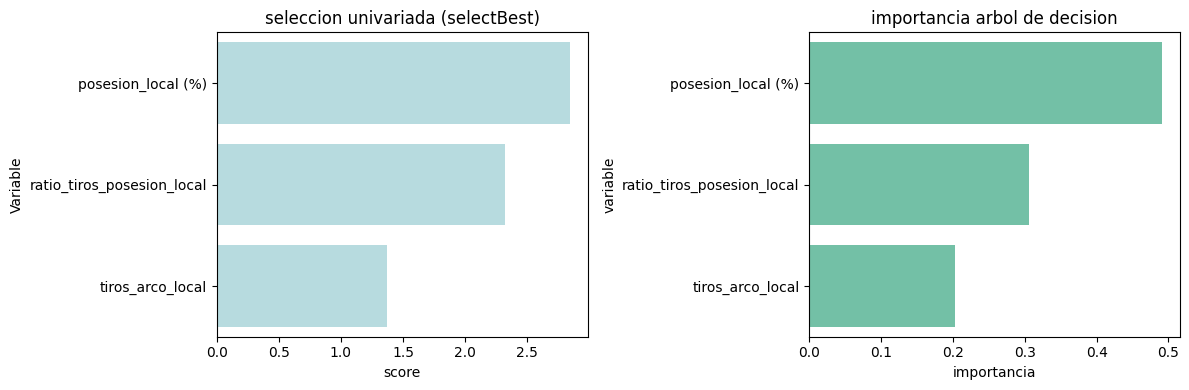

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# se crean dos ejes para mostrar ambos graficos
fig, ax = plt.subplots(1, 2, figsize=(12,4))

# grafica_selectbest (analisis univariados)
sns.barplot(x='score', y ='Variable', data=resultados, ax=ax[0], color='powderblue')
ax[0].set_title('seleccion univariada (selectBest)')

# grafica de importancia arbol de decision
sns.barplot(x='importancia', y='variable', data=resultado_importancia, ax=ax[1], color='mediumaquamarine')
ax[1].set_title('importancia arbol de decision')

plt.tight_layout()
plt.show()